# Function 8

## Check sys.path

In [1]:
# Checking that PYTHONPATH has been set to include local modules and included with sys.path

import os
try:
    print(f'PYTHONPATH:\n{os.environ['PYTHONPATH'].split(os.pathsep)}')
except KeyError:
    pass

import sys
print(f'\nsys.path:\n{'\n'.join(sys.path)}')

PYTHONPATH:
['C:\\Users\\antho\\Git\\LearningPython\\']

sys.path:
C:\Users\antho\Git\LearningPython
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\python314.zip
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\DLLs
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages


## Imports

In [2]:
# Load extension to auto re-import script changes without having to restart Python kernel 
%load_ext autoreload

# Set autoreload = 2 (reloads everything before every cell execution)
%autoreload 2

# Import scripts common across all BBOFunction notebooks. '%run' ensures variables/imports become part of this notebook's namespace
%run imports.py

## Function 8 Description

*You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown.*

*Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.*

*For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.*

## BBO parameters

In [3]:
func_no = 8
sub_week = 13

display(Markdown(f'**function number:** {func_no}'))
display(Markdown(f'**submission week:** {sub_week}'))

**function number:** 8

**submission week:** 13

## Load data

In [4]:
initial_len, y_pred, x_dim, x_col_names, df = data_helper.get_data(func_no, sub_week)

initial data points: 40
initial max: 9.598482002566342
submission data points: 12
current max: 9.997552331327 (from submission week: 10)
x_dim: 8


<br>**DataFrame:**

          x1        x2        x3        x4        x5        x6        x7  \
49  0.085302  0.186177  0.140901  0.163715  0.788822  0.504952  0.201794   
48  0.091306  0.185837  0.142897  0.156689  0.786691  0.518200  0.194771   
50  0.087778  0.190798  0.141126  0.156674  0.778435  0.508321  0.202829   
51  0.087541  0.190213  0.144789  0.163810  0.792933  0.512832  0.195778   
47  0.098047  0.182228  0.144726  0.166443  0.802861  0.526079  0.193138   
40  0.061206  0.179200  0.106062  0.120642  0.703601  0.525082  0.133696   
46  0.092418  0.212218  0.102869  0.000000  0.999999  0.562201  0.197517   
42  0.015322  0.114469  0.248797  0.080588  0.704195  0.592322  0.258471   
45  0.037213  0.238165  0.094312  0.016141  0.999999  0.374100  0.114115   
41  0.117642  0.338188  0.049996  0.312364  0.552527  0.581535  0.223949   
43  0.273058  0.149608  0.221175  0.116770  0.705827  0.332040  0.192713   
44  0.000000  0.000000  0.032869  0.499498  0.999999  0.647825  0.286892   
14  0.056447

### Manually omit columns or other data amends (if desired)

## Distance between x points

In [5]:
dists, min_dist, max_dist = distance_helper.distances_between_points(x = df[x_col_names].values)

#display(Markdown('**Distances between x points:**'))
#for row in dists:
#    print(f'{row}')

display(Markdown(f'**min_dist:** {min_dist}'))
display(Markdown(f'**max_dist:** {max_dist}'))

**min_dist:** 0.015986

**max_dist:** 1.835051

## Tune Gaussian Process surrogate model

### Setup hyperparameters to trial (kernels, x_tansform and y_transform)

In [6]:
kernels = gaussian_process_helper.get_kernels(x_dim)

print(kernels.keys())

dict_keys(['Matern 2.5', 'Matern 1.5', 'Matern 0.5', 'RBF', 'Rational Quad', 'Periodic', 'Locally Periodic', 'Linear + RBF', 'Matern 2.5 + WhiteK', 'Matern 1.5 + WhiteK', 'Matern 0.5 + WhiteK', 'RBF + WhiteK', 'Rational Quad + WhiteK', 'Periodic + WhiteK', 'Locally Periodic + WhiteK', 'Linear + RBF + WhiteK', 'Local Sens + Mat 2.5 + WhiteK', 'Ridge + RQ + WhiteK', 'Local Sens + Ridge + Mat 2.5 + WhiteK'])


In [7]:
y_transforms = transform_helper.get_y_transformers()

print(y_transforms.keys())

dict_keys(['none', 'scaled', 'power', 'pow-scaled', 'logshift', 'logshift-scaled'])


In [8]:
x_transforms = transform_helper.get_x_transformers()

print(x_transforms.keys())

dict_keys(['none', 'scaled'])


### Manually override hyperparameter options (if desired)

### Perform the hyperparameter tuning

In [9]:
df_tuning_results, model_dict = gaussian_process_helper.tune_gaussian_process_surrogate(
    df = df,
    x_col_names = x_col_names,
    kernels = kernels,
    y_transforms = y_transforms,
    x_transforms = x_transforms,
)


Matern 2.5, x:none, y:none...
         y_t    mean_t   resid_t     std_t    y_pred
49  9.997552  9.997459 -0.000093  0.000827  9.997459
48  9.997364  9.997471  0.000108  0.000437  9.997471
50  9.997296  9.997184 -0.000112  0.000624  9.997184
51  9.996868  9.996989  0.000122  0.001150  9.996989
47  9.995915  9.995619 -0.000296  0.001098  9.995619
40  9.978623  9.975539 -0.003084  0.009785  9.975539
46  9.929987  9.928754 -0.001233  0.041698  9.928754
42  9.917132  9.917351  0.000219  0.028805  9.917351
45  9.896000  9.942906  0.046905  0.050868  9.942906
41  9.879974  9.878687 -0.001287  0.027457  9.878687
43  9.878281  9.906897  0.028616  0.041940  9.906897
44  9.746762  9.798188  0.051426  0.065336  9.798188
14  9.598482  9.610040  0.011558  0.078075  9.610040
26  9.344274  9.352912  0.008638  0.063711  9.352912
39  9.183005  9.190469  0.007464  0.076889  9.190469
22  9.141639  9.174993  0.033353  0.080723  9.174993
19  9.013075  9.068629  0.055554  0.092424  9.068629
12  8.976554  8

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
49  9.997552  9.997380 -0.000172  0.000984  9.997380
48  9.997364  9.997489  0.000125  0.000583  9.997489
50  9.997296  9.997179 -0.000117  0.000822  9.997179
51  9.996868  9.997109  0.000241  0.001376  9.997109
47  9.995915  9.995579 -0.000336  0.001411  9.995579
40  9.978623  9.975201 -0.003422  0.012005  9.975201
46  9.929987  9.929678 -0.000309  0.042448  9.929678
42  9.917132  9.918265  0.001134  0.029487  9.918265
45  9.896000  9.943440  0.047440  0.052309  9.943440
41  9.879974  9.877141 -0.002833  0.030163  9.877141
43  9.878281  9.908805  0.030523  0.042651  9.908805
44  9.746762  9.801973  0.055211  0.067907  9.801973
14  9.598482  9.609986  0.011504  0.078944  9.609986
26  9.344274  9.352516  0.008241  0.064717  9.352516
39  9.183005  9.190097  0.007092  0.077408  9.190097
22  9.141639  9.174729  0.033089  0.081128  9.174729
19  9.013075  9.067624  0.054549  0.092919  9.067624
12  8.976554  8.978142  0.001588  0.081979  8.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t       resid_t     std_t    y_pred
49  1.388086  1.388087  5.693874e-08  0.000896  9.997552
48  1.387932  1.388213  2.816854e-04  0.000607  9.997707
50  1.387876  1.387576 -2.999441e-04  0.000789  9.996930
51  1.387525  1.387511 -1.378881e-05  0.001274  9.996851
47  1.386744  1.386036 -7.080951e-04  0.001498  9.995051
40  1.372569  1.367982 -4.586755e-03  0.012144  9.973028
46  1.332698  1.335092  2.393905e-03  0.040981  9.932907
42  1.322160  1.324620  2.459788e-03  0.026351  9.920132
45  1.304838  1.367628  6.279028e-02  0.049659  9.972596
41  1.291699  1.292135  4.355725e-04  0.026666  9.880505
43  1.290312  1.317414  2.710181e-02  0.037568  9.911341
44  1.182496  1.246143  6.364624e-02  0.063211  9.824401
14  1.060942  1.074060  1.311861e-02  0.073118  9.614485
26  0.852551  0.861664  9.113159e-03  0.058793  9.355391
39  0.720347  0.735332  1.498463e-02  0.068776  9.201284
22  0.686437  0.722979  3.654153e-02  0.071352  9.186215
19  0.581044  0.629927  4.88829

...

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


          y_t     mean_t   resid_t     std_t     y_pred
49  18.260371  18.261428  0.001057  0.002995   9.998004
48  18.259930  18.262633  0.002704  0.002348   9.998519
50  18.259772  18.257587 -0.002185  0.002620   9.996362
51  18.258769  18.256708 -0.002061  0.004502   9.995987
47  18.256540  18.248294 -0.008246  0.006476   9.992391
40  18.216089  18.196598 -0.019491  0.050169   9.970280
46  18.102434  18.026818 -0.075616  0.170630   9.897499
42  18.072424  18.076715  0.004291  0.109234   9.918935
45  18.023120  18.292471  0.269351  0.201946  10.011147
41  17.985749  18.004041  0.018293  0.098464   9.887790
43  17.981803  18.013423  0.031619  0.155697   9.891770
44  17.675882  17.903676  0.227795  0.213805   9.844610
14  17.332564  17.422113  0.089548  0.293103   9.636961
26  16.747949  16.716293 -0.031656  0.225843   9.330279
39  16.379695  16.444053  0.064358  0.259924   9.211029
22  16.285569  16.318289  0.032720  0.265221   9.155789
19  15.993895  16.027752  0.033857  0.343634   9

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t     y_pred
49  1.578132  1.577701 -0.000431  0.001129   9.995468
48  1.578093  1.578305  0.000212  0.000808   9.998394
50  1.578079  1.578068 -0.000011  0.000982   9.997244
51  1.577991  1.578498  0.000507  0.001745   9.999334
47  1.577794  1.576987 -0.000807  0.002066   9.992017
40  1.574218  1.577648  0.003430  0.016149   9.995839
46  1.564091  1.554161 -0.009930  0.049494   9.888566
42  1.561397  1.569133  0.007736  0.041097   9.958193
45  1.556953  1.607320  0.050367  0.059671  10.149961
41  1.553569  1.542530 -0.011039  0.039207   9.831658
43  1.553211  1.588590  0.035379  0.050686  10.054786
44  1.524991  1.587799  0.062808  0.066623  10.055489
14  1.492190  1.532027  0.039837  0.095417   9.800301
26  1.433325  1.420438 -0.012887  0.083464   9.305021
39  1.394101  1.387485 -0.006616  0.081868   9.169853
22  1.383787  1.376748 -0.007038  0.088312   9.129122
19  1.351034  1.363530  0.012496  0.110541   9.085570
12  1.341531  1.337649 -0.00

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Analytical Leave-One-Out Cross-Validation (LOOCV) Model Results

In [10]:
# Sort df_tuning_results:
# Mean-Square_Error (MSE) - The "best" kernel is the one with the lowest MSE    
# Log-Marginal Likelihood (LML) - The "best" kernel is the one with the highest LML
sort_columns = [Y_SMSE_TOP, Y_SMSE, Z_SMSE, LML]
sort_orders  = [      True,   True,   True, False]

#sort_columns = [Y_SMSE, Z_SMSE, LML]
#sort_orders  = [  True,   True, False]

df_tuning_results_sorted = df_tuning_results.sort_values(by=sort_columns, ascending=sort_orders)

# Format numeric display columns
display_cols = [MODEL, Z_SMSE, Y_SMSE, Y_SMSE_TOP, LML, KERNEL_PARAMS ]
for col in display_cols:
    df_tuning_results_sorted[col] = df_tuning_results_sorted[col].apply(format_sig_figs)

print(df_tuning_results_sorted[display_cols].to_string(index=False))

                                                             Model      Z_SMSE      Y_SMSE  Y_SMSE_TOP      LML                                                                                                                                                                                                              Kernel_Params
                                Linear + RBF, x:none, y:pow-scaled 2.91111e-05 2.87672e-05 2.90562e-05  55.9626                                                                                                                             DotProduct(sigma_0=10) + 3.03**2 * RBF(len_scale=[2.61, 3.64, 2.15, 3.54, 5.1, 3.59, 2.6, 10])
                                      Linear + RBF, x:none, y:none 0.000161236 0.000161236 3.44538e-05    46.97                                                                                                                              DotProduct(sigma_0=10) + 3.9**2 * RBF(len_scale=[2.7, 3.78, 2.21, 3.64, 5.22, 3.81, 2.7, 10])
       

## LOOCV Detailed Results for best model (Optionally override auto selected best model)

In [11]:
best_model_name = df_tuning_results_sorted[MODEL].iloc[0]

# Manually overriding best_model (optional)
override_model_name = None

if not override_model_name is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding best model from "{best_model_name}" to "{override_model_name}"**</span>'))
    best_model_name = override_model_name
    
best_model_dict = model_dict[best_model_name]
best_model = best_model_dict[MODEL]
x_transform = best_model_dict[X_TRANSFORM]
y_transform = best_model_dict[Y_TRANSFORM]

display(Markdown(f'<br>**Best model:**<br>{best_model_name}'))

params_str = extract_optimised_kernel_params_str(best_model)
display(Markdown(f'**Optimised parameters:**'))
print(params_str) # Own print() since it contains **

best_loocv_results = best_model_dict[LOOCV]

# Add the best model LOOCV results to df for easier display 
for label, content in best_loocv_results.items():
    df[label] = content

display(Markdown(f'<br>**LOOCV Predictions using best model:**<br>'))
print(df)

<br>**Best model:**<br>Linear + RBF, x:none, y:pow-scaled

**Optimised parameters:**

DotProduct(sigma_0=10) + 3.03**2 * RBF(len_scale=[2.61, 3.64, 2.15, 3.54, 5.1, 3.59, 2.6, 10])


<br>**LOOCV Predictions using best model:**<br>

          x1        x2        x3        x4        x5        x6        x7  \
49  0.085302  0.186177  0.140901  0.163715  0.788822  0.504952  0.201794   
48  0.091306  0.185837  0.142897  0.156689  0.786691  0.518200  0.194771   
50  0.087778  0.190798  0.141126  0.156674  0.778435  0.508321  0.202829   
51  0.087541  0.190213  0.144789  0.163810  0.792933  0.512832  0.195778   
47  0.098047  0.182228  0.144726  0.166443  0.802861  0.526079  0.193138   
40  0.061206  0.179200  0.106062  0.120642  0.703601  0.525082  0.133696   
46  0.092418  0.212218  0.102869  0.000000  0.999999  0.562201  0.197517   
42  0.015322  0.114469  0.248797  0.080588  0.704195  0.592322  0.258471   
45  0.037213  0.238165  0.094312  0.016141  0.999999  0.374100  0.114115   
41  0.117642  0.338188  0.049996  0.312364  0.552527  0.581535  0.223949   
43  0.273058  0.149608  0.221175  0.116770  0.705827  0.332040  0.192713   
44  0.000000  0.000000  0.032869  0.499498  0.999999  0.647825  0.286892   
14  0.056447

## y and y_t (y transformed) plots

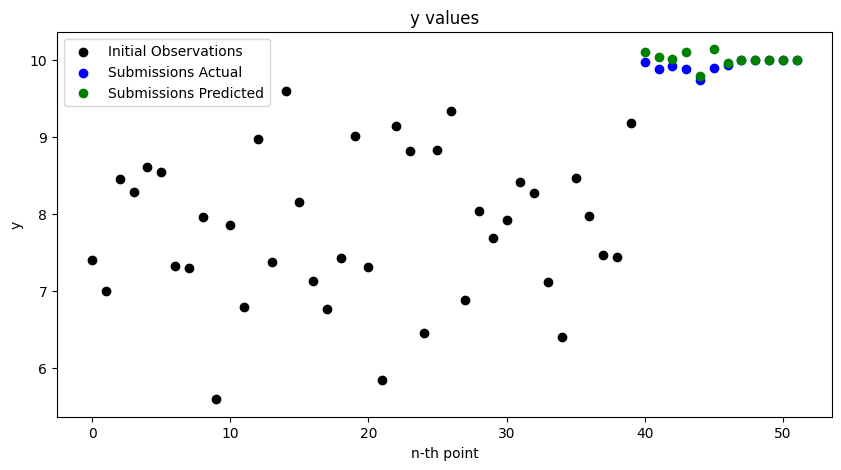

In [12]:
plot_helper.sequence_plot(df["y"], initial_len, y_pred)

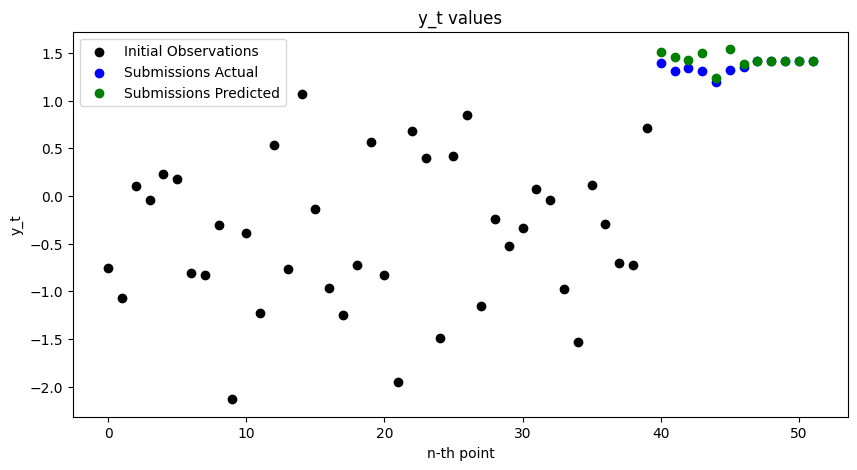

In [13]:
y_t_pred = y_transform.transform(y_pred)
plot_helper.sequence_plot(df["y_t"], initial_len, y_t_pred)

## Determine next evaluation point

### Create grid

In [14]:
x_grid = grid_helper.hypercube_grid([4, 4, 4, 4, 4, 4, 4, 4], x_col_names)

#print(x_grid[0:5])

len(x_grid): 390625


### Maximise UCB and EI acquisition functions

In [15]:
# Small xi (0.0 – 0.01) - Exploitation dominant
# Moderate xi (0.01 – 0.1) - Balanced
# Large xi (0.5+) Strong exploration
ei_xis = [ 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0 ]
ucb_betas = [ 10, 5, 2, 1, 0.5, 0.1, 0.05, 0.01, 0 ]
acq_fns = acquisition_fns_helper.get_acq_fns(df, y_transform, ei_xis = ei_xis, ucb_betas = ucb_betas)

# Bespoke bounds to force suggested next x near current x_best:
override_bounds = None # E.g. [(0.5, 0.9), (0.1, 0.4), ...]

if not override_bounds is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding acquisition function optimisation bounds to "{override_bounds}"**</span>'))

df_acq_results = acquisition_fns_helper.determine_next_eval_points(df, best_model, x_grid, x_col_names, x_transform, y_transform, x_dim, acq_fns, bounds = override_bounds, opt_trials=1000)

EI trans space (xi=2)...
Acq Fn([0.       0.999999 0.       0.999999 0.999999 0.       0.       0.999999]) = 1.0671442776958489e-104, distance: 1.249201800606663, y_t_best: [-0.1539543], y_best: [8.1445415]
EI trans space (xi=1)...
Acq Fn([0.       0.75     0.       0.999999 0.999999 0.       0.       0.999999]) = 2.914214130645335e-55, distance: 1.1803407284877532, y_t_best: [0.13445976], y_best: [8.494877]
EI trans space (xi=0.5)...
Acq Fn([0.       0.5      0.       0.999999 0.999999 0.       0.       0.999999]) = 7.356484944813755e-34, distance: 1.0953477691249478, y_t_best: [0.32490778], y_best: [8.72370802]
EI trans space (xi=0.1)...
Acq Fn([0.       0.5      0.       0.999999 0.999999 0.       0.       0.999999]) = 1.5589810137223887e-20, distance: 1.0953477691249478, y_t_best: [0.32490778], y_best: [8.72370802]
EI trans space (xi=0.05)...
Acq Fn([0.25 0.   0.   0.   0.5  0.75 0.25 0.  ]) = 2.1369376028112857e-16, distance: 0.6338357510625288, y_t_best: [1.16202756], y_best: [9.

### Display the acquisition function results

In [16]:
display(Markdown(f'<br>**EXISTING BEST:**'))
print(f'Actual y: {df['y'].iloc[0]}\nActual y_t: {df['y_t'].iloc[0]}\nx: {df[x_col_names].iloc[0].values}')

x_t = x_transform.transform(df[x_col_names].iloc[0].values.reshape(-1,x_dim))
y_t_mean, y_t_std = best_model.predict(np.atleast_2d(x_t), return_std=True)
y_mean, y_std = y_transform.inverse_transform_dist(y_t_mean, y_t_std)

display(Markdown(f'<br>**Model\'s [{best_model_name}] prediction at x corresponding to the best y.**'))
print(f'NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.')
print(f'y_t_mean: {y_t_mean}, y_t_std: {y_t_std}\ny_mean: {y_mean}\n')

# Add a y_mean ranking
df_acq_results['y_mean rank'] = df_acq_results['y_mean'].rank(ascending=False, method='min').astype(int)

display(Markdown(f'<br>**FUNCTION {func_no} SUBMISSION WEEK {sub_week}:**<br>'))
print(df_acq_results.to_string(index=False))

<br>**EXISTING BEST:**

Actual y: 9.997552331327
Actual y_t: 1.4137647500925759
x: [0.085302 0.186177 0.140901 0.163715 0.788822 0.504952 0.201794 0.57377 ]


<br>**Model's [Linear + RBF, x:none, y:pow-scaled] prediction at x corresponding to the best y.**

NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.
y_t_mean: [1.41377355], y_t_std: [9.49691862e-05]
y_mean: [9.9975624]



<br>**FUNCTION 8 SUBMISSION WEEK 13:**<br>

                     acq_fn                        ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']  distance  y_t_mean   y_mean  y_mean rank
      EI trans space (xi=2) 0.000000-0.999999-0.000000-0.999999-0.999999-0.000000-0.000000-0.999999  1.249202 -0.153954 8.144542           18
      EI trans space (xi=1) 0.000000-0.750000-0.000000-0.999999-0.999999-0.000000-0.000000-0.999999  1.180341  0.134460 8.494877           17
    EI trans space (xi=0.5) 0.000000-0.500000-0.000000-0.999999-0.999999-0.000000-0.000000-0.999999  1.095348  0.324908 8.723708           15
    EI trans space (xi=0.1) 0.000000-0.500000-0.000000-0.999999-0.999999-0.000000-0.000000-0.999999  1.095348  0.324908 8.723708           15
   EI trans space (xi=0.05) 0.250000-0.000000-0.000000-0.000000-0.500000-0.750000-0.250000-0.000000  0.633836  1.162028 9.707964            9
   EI trans space (xi=0.01) 0.250000-0.000000-0.000000-0.000000-0.500000-0.750000-0.250000-0.000000  0.633836  1.162028 9.707964            9
  EI t

## Manually calculating the prediction at an x point (Helper method)